# 🧠 Tumor-Type-Conditioned Multi-Task Brain MRI Segmentation
### Joint Classification + FiLM-Conditioned Segmentation, with Counterfactual Mask Explanations

**Dataset (Kaggle):** [Figshare Brain Tumor Dataset](https://www.kaggle.com/datasets/ashkhagan/figshare-brain-tumor-dataset) — 3,064 T1-weighted contrast-enhanced MRI slices from 233 patients (Cheng et al., 2017), each with **both** a tumor-type label (meningioma / glioma / pituitary) **and** a pixel-level tumor segmentation mask. 


## 1. Environment setup

In [ ]:
!pip install -q h5py albumentations kagglehub scikit-learn


In [1]:
import os
import glob
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import h5py
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("cache", exist_ok=True)

CLASS_NAMES = {1: "meningioma", 2: "glioma", 3: "pituitary"}
CLASS_TO_IDX = {1: 0, 2: 1, 3: 2}   # remap raw labels 1/2/3 -> 0/1/2 for CrossEntropyLoss
IDX_TO_NAME = {0: "meningioma", 1: "glioma", 2: "pituitary"}


Using device: cuda


## 2. Download the dataset

In [2]:
# OPTION A - kagglehub (Colab / local, needs Kaggle API credentials configured)
# import kagglehub
# dataset_path = kagglehub.dataset_download("ashkhagan/figshare-brain-tumor-dataset")

# OPTION B - classic Kaggle API (needs kaggle.json in ~/.kaggle/)
!kaggle datasets download -d ashkhagan/figshare-brain-tumor-dataset -p data --unzip
dataset_path = "data"

if os.path.exists("/kaggle/input/figshare-brain-tumor-dataset"):
    dataset_path = "/kaggle/input/figshare-brain-tumor-dataset"
else:
    dataset_path = "data"   # set manually after running Option A / B above

all_mat_files = sorted(glob.glob(os.path.join(dataset_path, "**", "*.mat"), recursive=True))
print("Found .mat files (before filtering):", len(all_mat_files))

def is_per_slice_file(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    return stem.isdigit()

mat_files = [p for p in all_mat_files if is_per_slice_file(p)]
excluded = [p for p in all_mat_files if p not in set(mat_files)]

print("Per-slice .mat files kept:", len(mat_files))
if excluded:
    print("Excluded non-slice files:", excluded)

assert len(mat_files) >= 2000, "Expected at least 2000 per-slice .mat files - check dataset_path / filtering rule"


Dataset URL: https://www.kaggle.com/datasets/ashkhagan/figshare-brain-tumor-dataset
License(s): CC-BY-SA-4.0
100%|█████████████████████████████████████████| 839M/839M [00:06<00:00, 146MB/s]

Found .mat files (before filtering): 3065
Per-slice .mat files kept: 3064
Excluded non-slice files: ['data/dataset/cvind.mat']


## 3. Parse the MATLAB v7.3 (.mat) files and cache as numpy arrays


In [3]:
def inspect_mat_structure(path, max_depth=3):
    # Diagnostic helper: prints every dataset path found inside a .mat (HDF5) file.
    found = []
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            found.append((name, obj.shape, obj.dtype))
    with h5py.File(path, "r") as f:
        f.visititems(visitor)
    return found


# Peek at the very first file so we can see the real layout before parsing everything
print("Root keys in first file:", list(h5py.File(mat_files[0], "r").keys()))
print("Full dataset structure of first file:")
for name, shape, dtype in inspect_mat_structure(mat_files[0]):
    print(f"  {name}  shape={shape}  dtype={dtype}")


Root keys in first file: ['cjdata']
Full dataset structure of first file:
  cjdata/PID  shape=(6, 1)  dtype=uint16
  cjdata/image  shape=(512, 512)  dtype=int16
  cjdata/label  shape=(1, 1)  dtype=float64
  cjdata/tumorBorder  shape=(1, 38)  dtype=float64
  cjdata/tumorMask  shape=(512, 512)  dtype=uint8


In [4]:
def _find_field(container, candidates):
    # Case-insensitive lookup of the first matching key name among `candidates` inside an h5py group/file.
    keys_lower = {k.lower(): k for k in container.keys()}
    for cand in candidates:
        if cand.lower() in keys_lower:
            return container[keys_lower[cand.lower()]]
    return None


def load_mat_record(path):
    with h5py.File(path, "r") as f:
        # Layout A: original Figshare style -> everything nested under a 'cjdata' struct group
        root = _find_field(f, ["cjdata"])
        container = root if root is not None else f   # Layout B: fields sit directly at file root

        image_ds = _find_field(container, ["image"])
        mask_ds = _find_field(container, ["tumorMask", "tumormask", "mask"])
        label_ds = _find_field(container, ["label"])
        pid_ds = _find_field(container, ["PID", "pid", "patientId", "patient_id"])

        if image_ds is None or mask_ds is None or label_ds is None:
            # Last resort: recursively search the whole file for anything dataset-shaped that matches
            all_datasets = inspect_mat_structure(path)
            raise KeyError(
                f"Could not find expected fields in {path}. "
                f"Datasets found in file: {all_datasets}. "
                f"Update _find_field candidate names above to match this layout."
            )

        image = np.array(image_ds).astype("float32")
        mask = np.array(mask_ds).astype("float32")
        label = int(np.array(label_ds).flatten()[0])

        if pid_ds is not None:
            try:
                pid = "".join(chr(c) for c in np.array(pid_ds).flatten())
            except Exception:
                pid = str(np.array(pid_ds).flatten()[0])
        else:
            pid = os.path.basename(path)   # fall back to filename as a pseudo patient id

    # MATLAB stores arrays column-major; transpose to get standard row-major image orientation
    if image.ndim == 2:
        image = image.T
    if mask.ndim == 2:
        mask = mask.T
    return image, mask, label, pid


# Sanity check on the first few files before running the full loop (robust to any single odd file)
_parsed_ok = False
for _test_path in mat_files[:5]:
    try:
        _img, _mask, _label, _pid = load_mat_record(_test_path)
        print(f"Parsed {_test_path} OK -> image shape {_img.shape}, mask shape {_mask.shape}, label {_label}, pid {_pid}")
        _parsed_ok = True
        break
    except Exception as e:
        print(f"Could not parse {_test_path}: {e}")

assert _parsed_ok, "None of the first 5 per-slice files parsed successfully - check the structure printed above."

CACHE_CSV = "cache/metadata.csv"

if os.path.exists(CACHE_CSV):
    meta_df = pd.read_csv(CACHE_CSV)
    print("Loaded cached metadata:", len(meta_df), "records")
else:
    rows = []
    skipped = []
    for i, path in enumerate(mat_files):
        try:
            image, mask, label, pid = load_mat_record(path)
        except Exception as e:
            skipped.append((path, str(e)))
            continue

        img_norm = image - image.min()
        img_norm = (img_norm / (img_norm.max() + 1e-8) * 255).astype("uint8")
        mask_bin = (mask > 0).astype("uint8") * 255

        img_cache_path = f"cache/img_{i:05d}.png"
        mask_cache_path = f"cache/mask_{i:05d}.png"
        cv2.imwrite(img_cache_path, img_norm)
        cv2.imwrite(mask_cache_path, mask_bin)

        rows.append({
            "mat_path": path,
            "image_path": img_cache_path,
            "mask_path": mask_cache_path,
            "label_raw": label,
            "label_idx": CLASS_TO_IDX[label],
            "label_name": CLASS_NAMES[label],
            "patient_id": pid,
        })
        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1}/{len(mat_files)}")

    if skipped:
        print(f"WARNING: skipped {len(skipped)} files that failed to parse. First few reasons:")
        for path, reason in skipped[:5]:
            print(f"  {path}: {reason}")

    meta_df = pd.DataFrame(rows)
    assert len(meta_df) >= 2000, (
        f"Only {len(meta_df)} slices parsed successfully (expected ~3064). "
        f"Check the printed dataset structure above and adjust _find_field candidates if needed."
    )
    meta_df.to_csv(CACHE_CSV, index=False)
    print("Cached", len(meta_df), "records to", CACHE_CSV)

meta_df.head()


Parsed data/dataset/data/1.mat OK -> image shape (512, 512), mask shape (512, 512), label 1, pid 100360
Processed 500/3064
Processed 1000/3064
Processed 1500/3064
Processed 2000/3064
Processed 2500/3064
Processed 3000/3064
Cached 3064 records to cache/metadata.csv


,mat_path,image_path,mask_path,label_raw,label_idx,label_name,patient_id
0,data/dataset/data/1.mat,cache/img_00000.png,cache/mask_00000.png,1,0,meningioma,100360
1,data/dataset/data/10.mat,cache/img_00001.png,cache/mask_00001.png,1,0,meningioma,101016
2,data/dataset/data/100.mat,cache/img_00002.png,cache/mask_00002.png,1,0,meningioma,107494
3,data/dataset/data/1000.mat,cache/img_00003.png,cache/mask_00003.png,3,2,pituitary,112649
4,data/dataset/data/1001.mat,cache/img_00004.png,cache/mask_00004.png,3,2,pituitary,112649


In [5]:
print("Total slices:", len(meta_df))
print("Total patients:", meta_df.patient_id.nunique())
print(meta_df.label_name.value_counts())


Total slices: 3064
Total patients: 233
label_name
glioma        1426
pituitary      930
meningioma     708
Name: count, dtype: int64


## 4. Exploratory visualisation — one example per tumor type

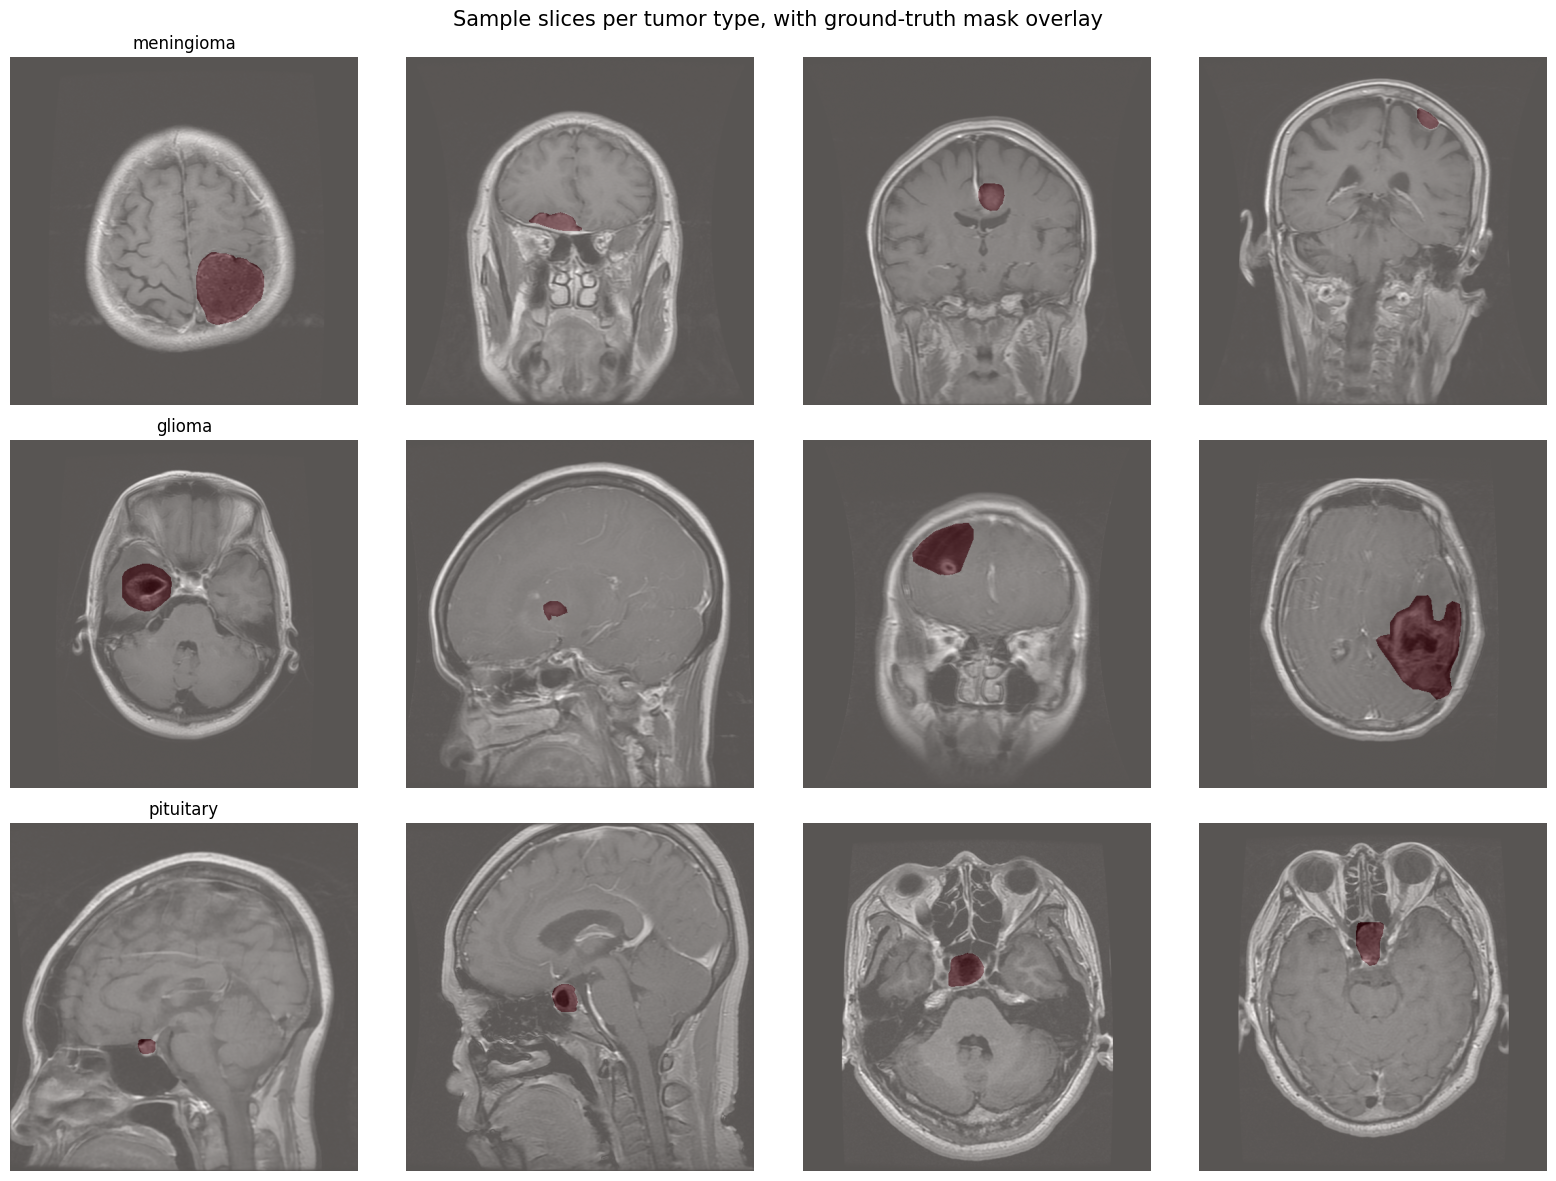

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row_i, (label_idx, name) in enumerate(IDX_TO_NAME.items()):
    samples = meta_df[meta_df.label_idx == label_idx].sample(4, random_state=SEED)
    for col_i, (_, r) in enumerate(samples.iterrows()):
        img = cv2.imread(r.image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(r.mask_path, cv2.IMREAD_GRAYSCALE)
        axes[row_i, col_i].imshow(img, cmap="gray")
        axes[row_i, col_i].imshow(mask, cmap="Reds", alpha=0.35)
        axes[row_i, col_i].set_title(name if col_i == 0 else "")
        axes[row_i, col_i].axis("off")
plt.suptitle("Sample slices per tumor type, with ground-truth mask overlay", fontsize=15)
plt.tight_layout()
plt.savefig("figures/samples_per_class.png", dpi=150)
plt.show()


## 5. Patient-level, class-stratified train / val / test split

As before we split by **patient ID** (not slice) to prevent leakage, and additionally stratify by the
**majority tumor type of each patient** so all three classes are represented proportionally in every split.

In [7]:
patient_label = meta_df.groupby("patient_id")["label_idx"].agg(lambda s: s.value_counts().idxmax())
patient_df = patient_label.reset_index().rename(columns={"label_idx": "majority_label"})

train_p, test_p = train_test_split(patient_df, test_size=0.20, stratify=patient_df.majority_label, random_state=SEED)
train_p, val_p = train_test_split(train_p, test_size=0.15, stratify=train_p.majority_label, random_state=SEED)

train_df = meta_df[meta_df.patient_id.isin(train_p.patient_id)].reset_index(drop=True)
val_df   = meta_df[meta_df.patient_id.isin(val_p.patient_id)].reset_index(drop=True)
test_df  = meta_df[meta_df.patient_id.isin(test_p.patient_id)].reset_index(drop=True)

print(f"Train: {len(train_df)} slices / {train_p.patient_id.nunique()} patients")
print(f"Val  : {len(val_df)} slices / {val_p.patient_id.nunique()} patients")
print(f"Test : {len(test_df)} slices / {test_p.patient_id.nunique()} patients")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, dict(d.label_name.value_counts()))


Train: 2122 slices / 158 patients
Val  : 331 slices / 28 patients
Test : 611 slices / 47 patients
train {'glioma': np.int64(1018), 'pituitary': np.int64(647), 'meningioma': np.int64(457)}
val {'glioma': np.int64(150), 'pituitary': np.int64(103), 'meningioma': np.int64(78)}
test {'glioma': np.int64(258), 'pituitary': np.int64(180), 'meningioma': np.int64(173)}


## 6. Dataset & augmentations

In [8]:
IMG_SIZE = 256

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2(),
])

eval_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2(),
])


class BrainTumorMultiTaskDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype("float32")

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        mask = mask.unsqueeze(0) if mask.ndim == 2 else mask
        label = int(row.label_idx)
        return img.float(), mask.float(), label


BATCH_SIZE = 16
train_ds = BrainTumorMultiTaskDataset(train_df, train_tf)
val_ds   = BrainTumorMultiTaskDataset(val_df, eval_tf)
test_ds  = BrainTumorMultiTaskDataset(test_df, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Batches -> train:", len(train_loader), " val:", len(val_loader), " test:", len(test_loader))


Batches -> train: 133  val: 21  test: 39


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 7. Model — shared encoder, classification head, FiLM-conditioned segmentation decoder

**FiLM (Feature-wise Linear Modulation)**: a small MLP maps the classification head's embedding to a
per-channel `(scale, shift)` pair for every decoder stage. Each decoder feature map is then transformed as
`gamma * x + beta` before its convolutions run. This lets the *same* decoder weights behave differently
depending on which tumor type the network believes it's segmenting — the network doesn't need three
separate segmentation heads, only three sets of modulation parameters it learns to produce.

In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        return x


class FiLM(nn.Module):
    # Produces per-channel (gamma, beta) from an embedding vector and applies them to a feature map.
    def __init__(self, embed_dim, num_channels):
        super().__init__()
        self.to_gamma_beta = nn.Linear(embed_dim, num_channels * 2)

    def forward(self, x, embedding):
        gb = self.to_gamma_beta(embedding)
        gamma, beta = gb.chunk(2, dim=1)
        gamma = gamma.unsqueeze(-1).unsqueeze(-1)
        beta = beta.unsqueeze(-1).unsqueeze(-1)
        return x * (1 + gamma) + beta


class FiLMDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, embed_dim, use_film=True):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)
        self.use_film = use_film
        if use_film:
            self.film = FiLM(embed_dim, out_ch + skip_ch)

    def forward(self, x, skip, embedding):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        if self.use_film:
            x = self.film(x, embedding)
        return self.conv(x)


class MultiTaskFiLMUNet(nn.Module):
    def __init__(self, in_ch=1, num_classes=3, base=32, embed_dim=64, use_film=True):
        super().__init__()
        chs = [base, base * 2, base * 4, base * 8, base * 16]
        self.use_film = use_film

        self.enc1 = ConvBlock(in_ch, chs[0])
        self.enc2 = ConvBlock(chs[0], chs[1])
        self.enc3 = ConvBlock(chs[1], chs[2])
        self.enc4 = ConvBlock(chs[2], chs[3])
        self.bottleneck = ConvBlock(chs[3], chs[4])
        self.pool = nn.MaxPool2d(2)

        # classification head, branches off the bottleneck features
        self.cls_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_embed = nn.Sequential(
            nn.Linear(chs[4], embed_dim), nn.ReLU(inplace=True), nn.Dropout(0.3)
        )
        self.cls_head = nn.Linear(embed_dim, num_classes)

        # segmentation decoder, conditioned on the classification embedding via FiLM
        self.dec4 = FiLMDecoderBlock(chs[4], chs[3], chs[3], embed_dim, use_film)
        self.dec3 = FiLMDecoderBlock(chs[3], chs[2], chs[2], embed_dim, use_film)
        self.dec2 = FiLMDecoderBlock(chs[2], chs[1], chs[1], embed_dim, use_film)
        self.dec1 = FiLMDecoderBlock(chs[1], chs[0], chs[0], embed_dim, use_film)
        self.seg_head = nn.Conv2d(chs[0], 1, 1)

    def forward(self, x, override_embedding=None):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        pooled = self.cls_pool(b).flatten(1)
        embedding = self.cls_embed(pooled)
        cls_logits = self.cls_head(embedding)

        # override_embedding lets us run the counterfactual experiment in Section 14:
        # force the decoder to condition on a *different* class's embedding than the one predicted.
        decode_embedding = override_embedding if override_embedding is not None else embedding

        d4 = self.dec4(b, e4, decode_embedding)
        d3 = self.dec3(d4, e3, decode_embedding)
        d2 = self.dec2(d3, e2, decode_embedding)
        d1 = self.dec1(d2, e1, decode_embedding)
        seg_logits = self.seg_head(d1)

        return seg_logits, cls_logits, embedding

print("Model defined: MultiTaskFiLMUNet (proposed), toggle use_film=False for the ablation baseline")


Model defined: MultiTaskFiLMUNet (proposed), toggle use_film=False for the ablation baseline


## 8. Losses & metrics for both tasks

In [13]:
class DiceLoss(nn.Module):
    def forward(self, pred, target, eps=1e-6):
        pred = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(1, 2, 3))
        union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        return 1 - ((2 * inter + eps) / (union + eps)).mean()


def dice_coefficient(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean()


def iou_score(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean()


class MultiTaskLoss(nn.Module):
    # weighted sum of segmentation loss (BCE+Dice) and classification loss (CE)
    def __init__(self, w_seg=0.6, w_cls=0.4):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.ce = nn.CrossEntropyLoss()
        self.w_seg, self.w_cls = w_seg, w_cls

    def forward(self, seg_pred, seg_target, cls_pred, cls_target):
        seg_loss = 0.5 * self.bce(seg_pred, seg_target) + 0.5 * self.dice(seg_pred, seg_target)
        cls_loss = self.ce(cls_pred, cls_target)
        total = self.w_seg * seg_loss + self.w_cls * cls_loss
        return total, seg_loss.item(), cls_loss.item()

print("Losses ready: MultiTaskLoss, dice_coefficient, iou_score")


Losses ready: MultiTaskLoss, dice_coefficient, iou_score


## 9. Training loop

In [14]:
def train_multitask(model, model_name, train_loader, val_loader, epochs=40, lr=1e-3, patience=8):
    model = model.to(DEVICE)
    criterion = MultiTaskLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": [], "val_acc": [], "val_score": []}
    best_score, no_improve = -1.0, 0
    ckpt_path = f"checkpoints/{model_name}_best.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, masks, labels in train_loader:
            imgs, masks, labels = imgs.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            seg_pred, cls_pred, _ = model(imgs)
            loss, _, _ = criterion(seg_pred, masks, cls_pred, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, val_dice, val_iou, correct, total = 0.0, 0.0, 0.0, 0, 0
        with torch.no_grad():
            for imgs, masks, labels in val_loader:
                imgs, masks, labels = imgs.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
                seg_pred, cls_pred, _ = model(imgs)
                loss, _, _ = criterion(seg_pred, masks, cls_pred, labels)
                val_loss += loss.item() * imgs.size(0)
                val_dice += dice_coefficient(seg_pred, masks).item() * imgs.size(0)
                val_iou += iou_score(seg_pred, masks).item() * imgs.size(0)
                correct += (cls_pred.argmax(1) == labels).sum().item()
                total += imgs.size(0)
        n = len(val_loader.dataset)
        val_loss, val_dice, val_iou = val_loss / n, val_dice / n, val_iou / n
        val_acc = correct / total
        val_score = 0.6 * val_dice + 0.4 * val_acc   # combined checkpoint criterion

        scheduler.step(val_score)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)
        history["val_acc"].append(val_acc)
        history["val_score"].append(val_score)

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} | train_loss {train_loss:.4f} | "
              f"val_dice {val_dice:.4f} | val_iou {val_iou:.4f} | val_acc {val_acc:.4f} | score {val_score:.4f}")

        if val_score > best_score:
            best_score = val_score
            no_improve = 0
            torch.save({"model_state": model.state_dict(), "val_score": val_score, "epoch": epoch}, ckpt_path)
            print(f"   -> saved new best checkpoint (score={val_score:.4f})")
        # else:
        #     no_improve += 1
        #     if no_improve >= patience:
        #         print("   -> early stopping")
        #         break

    with open(f"checkpoints/{model_name}_history.json", "w") as f:
        json.dump(history, f)
    return history, ckpt_path


## 10. Train the proposed FiLM-conditioned model and the no-FiLM ablation baseline

> Set `EPOCHS` higher (40+) for a full run; kept modest here so the notebook can be sanity-checked quickly.

In [15]:
EPOCHS = 200

proposed_model = MultiTaskFiLMUNet(in_ch=1, num_classes=3, base=32, embed_dim=64, use_film=True)
history_proposed, ckpt_proposed = train_multitask(
    proposed_model, "filmnet_proposed", train_loader, val_loader, epochs=EPOCHS
)


[filmnet_proposed] Epoch 01/200 | train_loss 0.7148 | val_dice 0.0435 | val_iou 0.0307 | val_acc 0.7251 | score 0.3161
   -> saved new best checkpoint (score=0.3161)
[filmnet_proposed] Epoch 02/200 | train_loss 0.6132 | val_dice 0.1369 | val_iou 0.0888 | val_acc 0.4924 | score 0.2791
[filmnet_proposed] Epoch 03/200 | train_loss 0.5598 | val_dice 0.2672 | val_iou 0.1957 | val_acc 0.7341 | score 0.4540
   -> saved new best checkpoint (score=0.4540)
[filmnet_proposed] Epoch 04/200 | train_loss 0.4800 | val_dice 0.2272 | val_iou 0.1590 | val_acc 0.4955 | score 0.3345
[filmnet_proposed] Epoch 05/200 | train_loss 0.4480 | val_dice 0.3540 | val_iou 0.2439 | val_acc 0.7160 | score 0.4988
   -> saved new best checkpoint (score=0.4988)
[filmnet_proposed] Epoch 06/200 | train_loss 0.4291 | val_dice 0.3616 | val_iou 0.2662 | val_acc 0.8187 | score 0.5444
   -> saved new best checkpoint (score=0.5444)
[filmnet_proposed] Epoch 07/200 | train_loss 0.3873 | val_dice 0.4332 | val_iou 0.3174 | val_acc 0

In [16]:
baseline_model = MultiTaskFiLMUNet(in_ch=1, num_classes=3, base=32, embed_dim=64, use_film=False)
history_baseline, ckpt_baseline = train_multitask(
    baseline_model, "multitask_nofilm_baseline", train_loader, val_loader, epochs=EPOCHS
)


[multitask_nofilm_baseline] Epoch 01/200 | train_loss 0.6805 | val_dice 0.0360 | val_iou 0.0232 | val_acc 0.5408 | score 0.2379
   -> saved new best checkpoint (score=0.2379)
[multitask_nofilm_baseline] Epoch 02/200 | train_loss 0.5336 | val_dice 0.2288 | val_iou 0.1624 | val_acc 0.7160 | score 0.4237
   -> saved new best checkpoint (score=0.4237)
[multitask_nofilm_baseline] Epoch 03/200 | train_loss 0.4458 | val_dice 0.2643 | val_iou 0.1847 | val_acc 0.6798 | score 0.4305
   -> saved new best checkpoint (score=0.4305)
[multitask_nofilm_baseline] Epoch 04/200 | train_loss 0.3956 | val_dice 0.3640 | val_iou 0.2619 | val_acc 0.8278 | score 0.5495
   -> saved new best checkpoint (score=0.5495)
[multitask_nofilm_baseline] Epoch 05/200 | train_loss 0.3730 | val_dice 0.1901 | val_iou 0.1137 | val_acc 0.6979 | score 0.3932
[multitask_nofilm_baseline] Epoch 06/200 | train_loss 0.3503 | val_dice 0.4632 | val_iou 0.3569 | val_acc 0.8278 | score 0.6091
   -> saved new best checkpoint (score=0.609

## 11. Training curves

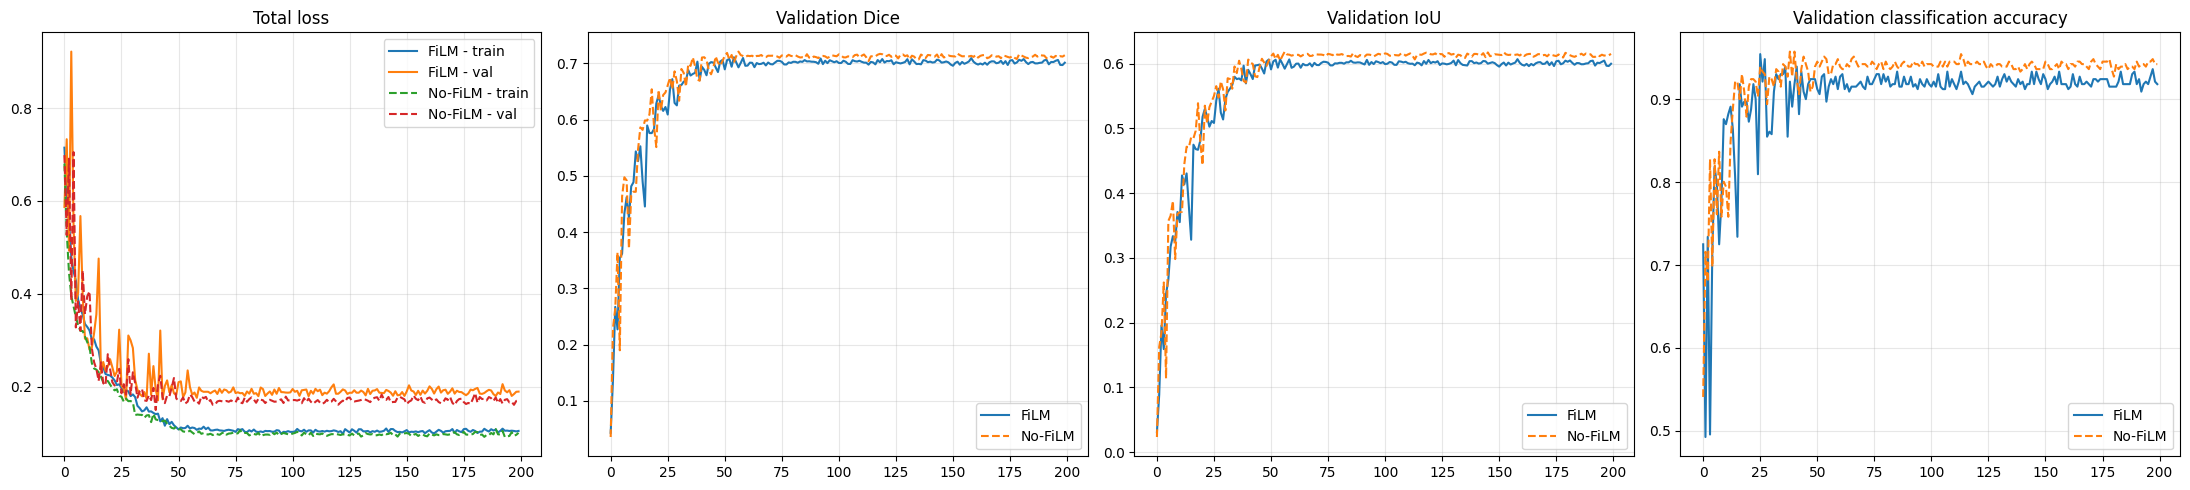

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].plot(history_proposed["train_loss"], label="FiLM - train")
axes[0].plot(history_proposed["val_loss"], label="FiLM - val")
axes[0].plot(history_baseline["train_loss"], "--", label="No-FiLM - train")
axes[0].plot(history_baseline["val_loss"], "--", label="No-FiLM - val")
axes[0].set_title("Total loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_proposed["val_dice"], label="FiLM")
axes[1].plot(history_baseline["val_dice"], "--", label="No-FiLM")
axes[1].set_title("Validation Dice"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history_proposed["val_iou"], label="FiLM")
axes[2].plot(history_baseline["val_iou"], "--", label="No-FiLM")
axes[2].set_title("Validation IoU"); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(history_proposed["val_acc"], label="FiLM")
axes[3].plot(history_baseline["val_acc"], "--", label="No-FiLM")
axes[3].set_title("Validation classification accuracy"); axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/training_curves.png", dpi=150)
plt.show()


## 12. Test-set evaluation: overall + per-tumor-type Dice, confusion matrix, ablation comparison

In [18]:
def evaluate_multitask(model, ckpt_path, loader):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE).eval()

    all_preds, all_labels = [], []
    per_class_dice = {0: [], 1: [], 2: []}
    with torch.no_grad():
        for imgs, masks, labels in loader:
            imgs, masks, labels = imgs.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
            seg_pred, cls_pred, _ = model(imgs)
            preds = cls_pred.argmax(1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            for i in range(imgs.size(0)):
                d = dice_coefficient(seg_pred[i:i+1], masks[i:i+1]).item()
                per_class_dice[labels[i].item()].append(d)

    overall_dice = np.mean([d for lst in per_class_dice.values() for d in lst])
    per_class_mean = {IDX_TO_NAME[k]: (np.mean(v) if v else float("nan")) for k, v in per_class_dice.items()}
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return overall_dice, per_class_mean, acc, all_preds, all_labels


proposed_eval = evaluate_multitask(MultiTaskFiLMUNet(use_film=True), ckpt_proposed, test_loader)
baseline_eval = evaluate_multitask(MultiTaskFiLMUNet(use_film=False), ckpt_baseline, test_loader)

print("Proposed (FiLM)  -> overall Dice: {:.4f} | acc: {:.4f} | per-class Dice: {}".format(
    proposed_eval[0], proposed_eval[2], proposed_eval[1]))
print("Baseline(no-FiLM)-> overall Dice: {:.4f} | acc: {:.4f} | per-class Dice: {}".format(
    baseline_eval[0], baseline_eval[2], baseline_eval[1]))


Proposed (FiLM)  -> overall Dice: 0.7401 | acc: 0.9280 | per-class Dice: {'meningioma': np.float64(0.8973322369890406), 'glioma': np.float64(0.5681897136101439), 'pituitary': np.float64(0.8352613243791792)}
Baseline(no-FiLM)-> overall Dice: 0.7372 | acc: 0.9247 | per-class Dice: {'meningioma': np.float64(0.8818094107405972), 'glioma': np.float64(0.5773300622494923), 'pituitary': np.float64(0.827232556587941)}


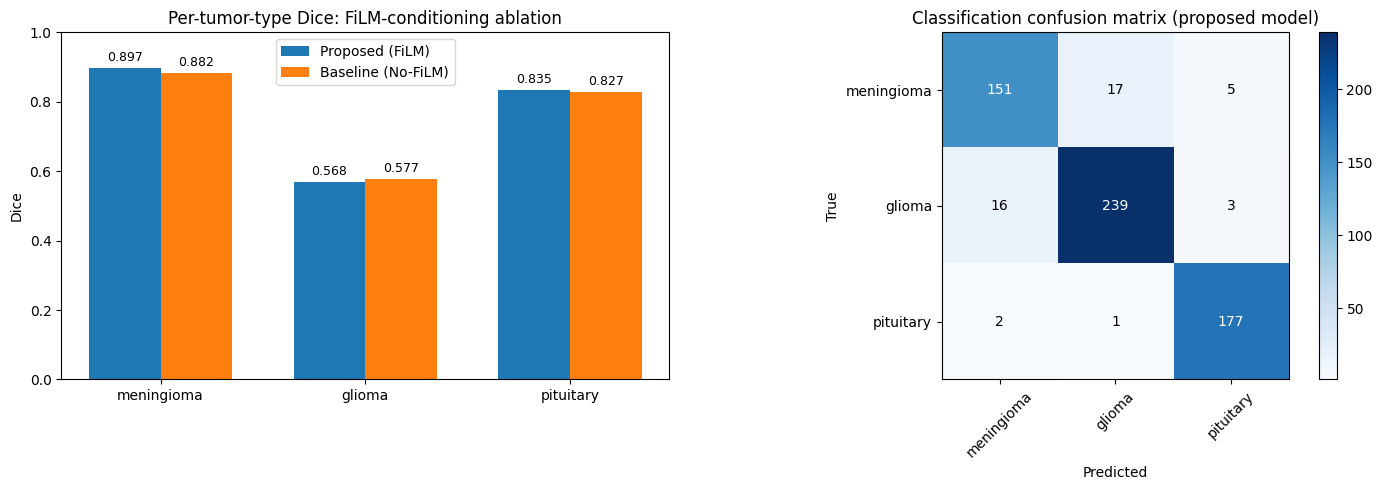

              precision    recall  f1-score   support

  meningioma       0.89      0.87      0.88       173
      glioma       0.93      0.93      0.93       258
   pituitary       0.96      0.98      0.97       180

    accuracy                           0.93       611
   macro avg       0.93      0.93      0.93       611
weighted avg       0.93      0.93      0.93       611



In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(IDX_TO_NAME.values())
prop_vals = [proposed_eval[1][n] for n in names]
base_vals = [baseline_eval[1][n] for n in names]
x = np.arange(len(names)); width = 0.35
axes[0].bar(x - width/2, prop_vals, width, label="Proposed (FiLM)")
axes[0].bar(x + width/2, base_vals, width, label="Baseline (No-FiLM)")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Dice")
axes[0].set_title("Per-tumor-type Dice: FiLM-conditioning ablation")
axes[0].legend()
for i, v in enumerate(prop_vals):
    axes[0].text(i - width/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(base_vals):
    axes[0].text(i + width/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

cm = confusion_matrix(proposed_eval[4], proposed_eval[3])
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(names, rotation=45)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(names)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Classification confusion matrix (proposed model)")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig("figures/perclass_dice_and_confusion.png", dpi=150)
plt.show()

print(classification_report(proposed_eval[4], proposed_eval[3], target_names=names))


## 13. Cross-task explainability: where does the classifier look vs. where does the segmenter look?

Grad-CAM on the bottleneck features (driving the classification head) compared against a gradient-based
saliency map on the input (driving the segmentation head), for the same slice.

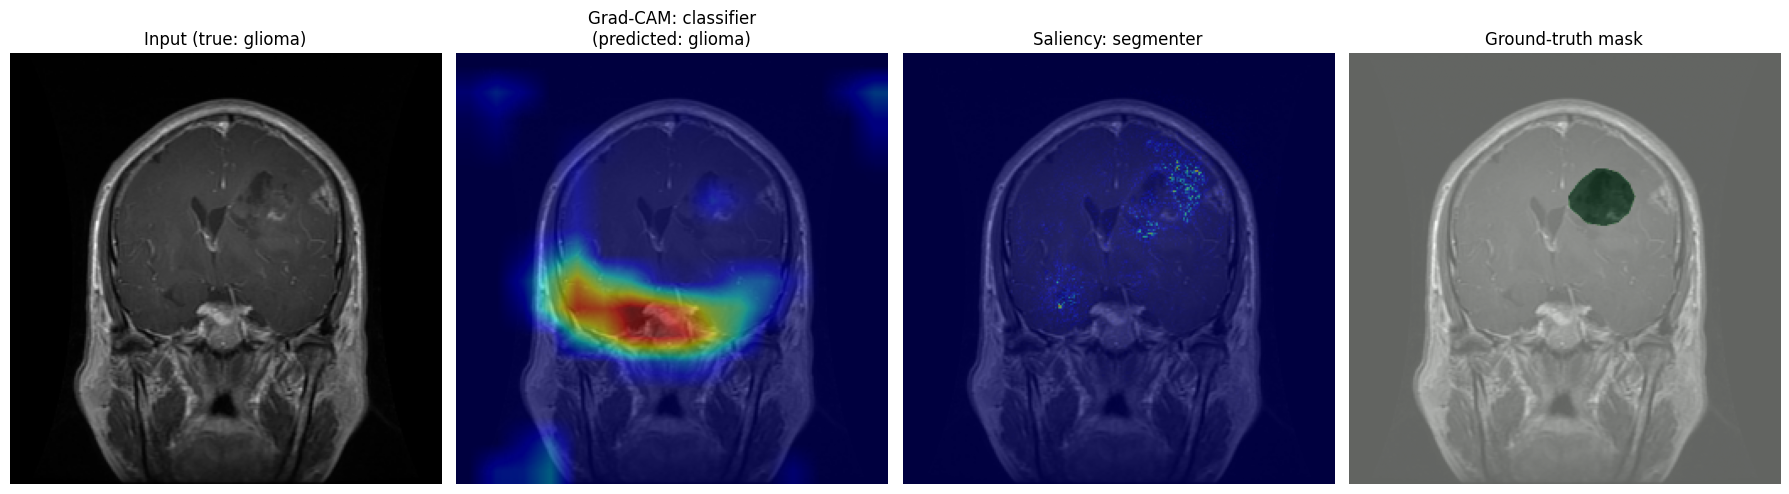

In [20]:
def grad_cam_classifier(model, image_tensor, target_class=None):
    model.eval()
    activations = {}
    gradients = {}

    def fwd_hook(module, inp, out):
        activations["value"] = out

    def bwd_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    h1 = model.bottleneck.conv2.register_forward_hook(fwd_hook)
    h2 = model.bottleneck.conv2.register_full_backward_hook(bwd_hook)

    seg_pred, cls_pred, _ = model(image_tensor)
    if target_class is None:
        target_class = cls_pred.argmax(1).item()
    score = cls_pred[0, target_class]
    model.zero_grad()
    score.backward()

    h1.remove(); h2.remove()

    acts = activations["value"][0].detach().cpu().numpy()
    grads = gradients["value"][0].detach().cpu().numpy()
    weights = grads.mean(axis=(1, 2))
    cam = np.maximum((weights[:, None, None] * acts).sum(axis=0), 0)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, target_class


def segmentation_saliency(model, image_tensor):
    model.eval()
    image_tensor = image_tensor.clone().detach().requires_grad_(True)
    seg_pred, cls_pred, _ = model(image_tensor)
    score = torch.sigmoid(seg_pred).sum()
    model.zero_grad()
    score.backward()
    sal = image_tensor.grad.abs().squeeze().cpu().numpy()
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal


row = test_df[test_df.label_name == "glioma"].sample(1, random_state=SEED).iloc[0]
img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
mask = (cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE) > 127).astype("float32")
augmented = eval_tf(image=img, mask=mask)
img_tensor = augmented["image"].unsqueeze(0).to(DEVICE).float()

cam, pred_class = grad_cam_classifier(proposed_model, img_tensor)
sal = segmentation_saliency(proposed_model, img_tensor)
resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(resized_img, cmap="gray"); axes[0].set_title(f"Input (true: {row.label_name})"); axes[0].axis("off")
axes[1].imshow(resized_img, cmap="gray"); axes[1].imshow(cam, cmap="jet", alpha=0.5)
axes[1].set_title(f"Grad-CAM: classifier\n(predicted: {IDX_TO_NAME[pred_class]})"); axes[1].axis("off")
axes[2].imshow(resized_img, cmap="gray"); axes[2].imshow(sal, cmap="jet", alpha=0.5)
axes[2].set_title("Saliency: segmenter"); axes[2].axis("off")
axes[3].imshow(resized_img, cmap="gray"); axes[3].imshow(mask if mask.shape == (IMG_SIZE, IMG_SIZE) else cv2.resize(mask, (IMG_SIZE, IMG_SIZE)), cmap="Greens", alpha=0.4)
axes[3].set_title("Ground-truth mask"); axes[3].axis("off")
plt.tight_layout()
plt.savefig("figures/cross_task_explainability.png", dpi=150)
plt.show()


## 14. 🌟 Counterfactual mask probing: "what if the model thought this was a different tumor type?"

This is the signature experiment of this project. I take a single slice, run the encoder + classifier
once to get the real predicted embedding, then **manually override** the embedding fed into the FiLM layers
with the *mean training embedding of each of the three classes* in turn — forcing the same encoder features
through three different "tumor-type conditioning" settings — and compare the three resulting masks.

If FiLM conditioning is doing something real, the meningioma-conditioned decoding and the glioma-conditioned
decoding should produce visibly different mask shapes/sizes/margins from the same underlying features.

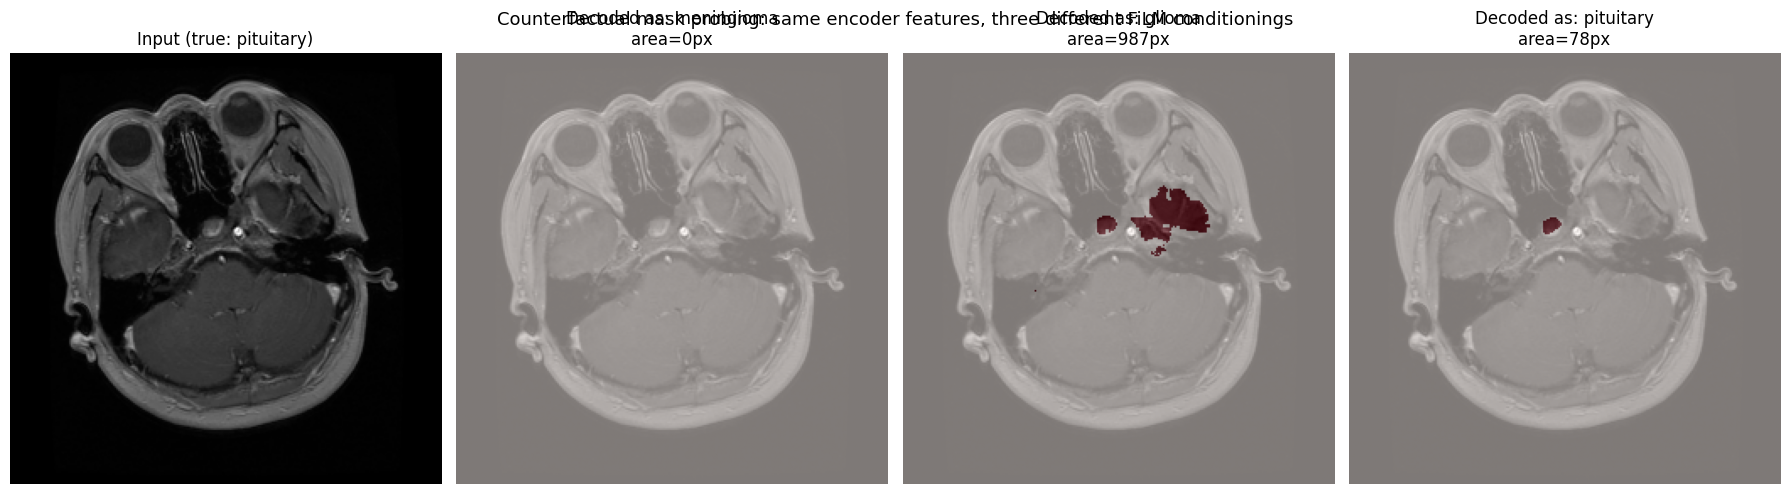

In [21]:
# Step 1: compute the mean embedding per class over a sample of the training set (a class "prototype")
proposed_model.eval()
class_embeddings = {0: [], 1: [], 2: []}
with torch.no_grad():
    for imgs, masks, labels in train_loader:
        imgs = imgs.to(DEVICE)
        _, _, embed = proposed_model(imgs)
        for e, l in zip(embed.cpu().numpy(), labels.numpy()):
            class_embeddings[l].append(e)
        if sum(len(v) for v in class_embeddings.values()) > 300:  # a few hundred samples is enough
            break

class_prototypes = {k: torch.tensor(np.mean(v, axis=0), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                     for k, v in class_embeddings.items() if len(v) > 0}

# Step 2: pick one test slice and decode it under each class prototype's conditioning
row = test_df.sample(1, random_state=SEED).iloc[0]
img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
mask = (cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE) > 127).astype("float32")
augmented = eval_tf(image=img, mask=mask)
img_tensor = augmented["image"].unsqueeze(0).to(DEVICE).float()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
axes[0].imshow(resized_img, cmap="gray"); axes[0].set_title(f"Input (true: {row.label_name})"); axes[0].axis("off")

with torch.no_grad():
    for i, (class_idx, proto) in enumerate(sorted(class_prototypes.items())):
        seg_logits, _, _ = proposed_model(img_tensor, override_embedding=proto)
        pred_mask = (torch.sigmoid(seg_logits) > 0.5).float().cpu().numpy()[0, 0]
        axes[i + 1].imshow(resized_img, cmap="gray")
        axes[i + 1].imshow(pred_mask, cmap="Reds", alpha=0.5)
        area_px = pred_mask.sum()
        axes[i + 1].set_title(f"Decoded as: {IDX_TO_NAME[class_idx]}\narea={int(area_px)}px")
        axes[i + 1].axis("off")

plt.suptitle("Counterfactual mask probing: same encoder features, three different FiLM conditionings", fontsize=13)
plt.tight_layout()
plt.savefig("figures/counterfactual_probing.png", dpi=150)
plt.show()


## 15. Automated per-patient report with a cross-task disagreement flag

For every test slice: predicted tumor type + confidence, predicted tumor area (px & mm²), and a **flag**
raised when either (a) classification confidence is low, or (b) the mask predicted under the model's own
predicted class prototype differs substantially in area from the mask predicted under the *runner-up*
class's prototype — i.e. the segmentation is unstable to the classification decision, a sign the case is
genuinely ambiguous and worth a second look.

In [22]:
PIXEL_SPACING_MM2 = 1.0  # approx.; refine with real DICOM spacing if available

report_rows = []
proposed_model.eval()
with torch.no_grad():
    for _, row in test_df.iterrows():
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        mask = (cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE) > 127).astype("float32")
        augmented = eval_tf(image=img, mask=mask)
        img_tensor = augmented["image"].unsqueeze(0).to(DEVICE).float()

        seg_logits, cls_logits, embed = proposed_model(img_tensor)
        probs = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
        pred_class = int(probs.argmax())
        confidence = float(probs[pred_class])
        runner_up = int(np.argsort(probs)[-2])

        pred_mask_main = (torch.sigmoid(seg_logits) > 0.5).float().cpu().numpy()[0, 0]
        area_main = float(pred_mask_main.sum())

        if runner_up in class_prototypes:
            seg_logits_alt, _, _ = proposed_model(img_tensor, override_embedding=class_prototypes[runner_up])
            pred_mask_alt = (torch.sigmoid(seg_logits_alt) > 0.5).float().cpu().numpy()[0, 0]
            area_alt = float(pred_mask_alt.sum())
        else:
            area_alt = area_main

        area_disagreement = abs(area_main - area_alt) / (area_main + 1e-6)

        report_rows.append({
            "patient_id": row.patient_id,
            "slice_file": os.path.basename(row.image_path),
            "true_label": row.label_name,
            "predicted_label": IDX_TO_NAME[pred_class],
            "confidence": confidence,
            "predicted_tumor_area_px": area_main,
            "predicted_tumor_area_mm2": area_main * PIXEL_SPACING_MM2,
            "area_disagreement_vs_runnerup_class": area_disagreement,
            "flag_low_confidence": confidence < 0.6,
            "flag_unstable_segmentation": area_disagreement > 0.5,
        })

report_df = pd.DataFrame(report_rows)
report_df["needs_review"] = report_df["flag_low_confidence"] | report_df["flag_unstable_segmentation"]
report_df.to_csv("reports/slice_level_report.csv", index=False)

print(f"Slices flagged for review: {report_df['needs_review'].sum()} / {len(report_df)}")
report_df.sort_values("area_disagreement_vs_runnerup_class", ascending=False).head(10)


Slices flagged for review: 294 / 611


,patient_id,slice_file,true_label,predicted_label,confidence,predicted_tumor_area_px,predicted_tumor_area_mm2,area_disagreement_vs_runnerup_class,flag_low_confidence,flag_unstable_segmentation,needs_review
190,MR049453,img_01017.png,glioma,glioma,1.000000,0.0,0.0,1.000000e+07,False,True,True
585,92897,img_02934.png,glioma,meningioma,0.733267,15.0,15.0,1.640000e+01,False,True,True
533,102075,img_02757.png,glioma,pituitary,0.985947,6.0,6.0,1.283333e+01,False,True,True
150,102648,img_00743.png,pituitary,pituitary,0.952399,369.0,369.0,4.271003e+00,False,True,True
191,MR049453,img_01018.png,glioma,glioma,1.000000,32.0,32.0,3.593750e+00,False,True,True
73,112847,img_00293.png,pituitary,pituitary,0.949695,384.0,384.0,3.585937e+00,False,True,True
86,102648,img_00336.png,pituitary,pituitary,0.966865,194.0,194.0,3.412371e+00,False,True,True
547,102075,img_02800.png,glioma,meningioma,0.744576,217.0,217.0,3.161290e+00,False,True,True
154,102648,img_00747.png,pituitary,pituitary,0.953503,50.0,50.0,2.040000e+00,False,True,True
83,102648,img_00331.png,pituitary,pituitary,0.999619,46.0,46.0,1.847826e+00,False,True,True


In [23]:
patient_summary = report_df.groupby("patient_id").agg(
    n_slices=("slice_file", "count"),
    dominant_predicted_type=("predicted_label", lambda s: s.value_counts().idxmax()),
    mean_confidence=("confidence", "mean"),
    total_tumor_area_mm2=("predicted_tumor_area_mm2", "sum"),
    slices_needing_review=("needs_review", "sum"),
).reset_index().sort_values("total_tumor_area_mm2", ascending=False)

patient_summary.to_csv("reports/patient_summary_report.csv", index=False)
patient_summary.head(10)


,patient_id,n_slices,dominant_predicted_type,mean_confidence,total_tumor_area_mm2,slices_needing_review
39,MR040240,28,glioma,0.998981,42793.0,11
35,MR026175E,22,glioma,0.999738,38625.0,21
37,MR033389B,24,glioma,0.999294,37119.0,17
38,MR037458C,19,glioma,0.990997,29695.0,15
45,MR051796,20,glioma,0.999644,29073.0,14
42,MR049453,25,glioma,0.999992,27834.0,16
17,108514,18,meningioma,0.859830,26670.0,4
43,MR050791B,22,glioma,0.967950,26652.0,21
13,106494,18,glioma,0.943665,23622.0,14
21,112002,12,glioma,0.935781,21448.0,9
